In [1]:
from os.path import dirname, abspath,join
from os import makedirs
import sys
import numpy as np
import pandas as pd
import json
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

root_path = dirname(abspath("./"))
import sys
sys.path.append(root_path)
from causaliT.evaluation.predict import *
from causaliT.evaluation.eval_sweeps import eval_gradients
from causaliT.training.forecasters.transformer_forecaster import TransformerForecaster

# plotting standard settings
plt.rcParams['figure.dpi'] = 100 #360 # standard is 360 but for set to 100 for practical visualization on the notebook
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['lines.linewidth'] = 1.5

In [2]:
experiment = "../experiments/SoftMax_scm5_54013794"
df = eval_gradients(experiment)



df["PA"] = df["j"].map({
    0:"$X_1$",
    1:"$X_2$",
    2:"$X_3$",
})
df.head()

reached bottom level: gradients
Processing gradients in gradients...
  Found 10 npz files
  Processed jacobian_epoch_0000.npz (epoch 0, 125 batches)
  Processed jacobian_epoch_0001.npz (epoch 1, 125 batches)
  Processed jacobian_epoch_0002.npz (epoch 2, 125 batches)
  Processed jacobian_epoch_0003.npz (epoch 3, 125 batches)
  Processed jacobian_epoch_0004.npz (epoch 4, 125 batches)
  Processed jacobian_epoch_0005.npz (epoch 5, 125 batches)
  Processed jacobian_epoch_0006.npz (epoch 6, 125 batches)
  Processed jacobian_epoch_0007.npz (epoch 7, 125 batches)
  Processed jacobian_epoch_0008.npz (epoch 8, 125 batches)
  Processed jacobian_epoch_0009.npz (epoch 9, 125 batches)
Total gradient records: 720000
reached bottom level: gradients
Processing gradients in gradients...
  Found 10 npz files
  Processed jacobian_epoch_0000.npz (epoch 0, 125 batches)
  Processed jacobian_epoch_0001.npz (epoch 1, 125 batches)
  Processed jacobian_epoch_0002.npz (epoch 2, 125 batches)
  Processed jacobian_e

,sample,i,j,value,epoch,batch,level_1,level_0,PA
0,0,0,0,0.191350,0,batch_0,gradients,k_0,$X_1$
1,0,0,1,0.114352,0,batch_0,gradients,k_0,$X_2$
2,0,0,2,0.270664,0,batch_0,gradients,k_0,$X_3$
3,0,1,0,0.281256,0,batch_0,gradients,k_0,$X_1$
4,0,1,1,0.190568,0,batch_0,gradients,k_0,$X_2$


In [4]:


def denormalize(grad_scaled, dataset, datadir_path):
    import json
    with open(join(datadir_path, dataset, "normalization.json"), 'r', encoding='utf-8') as f:
        norm_dict = json.load(f)
    
    if norm_dict["input"]["method"] == "minmax" and norm_dict["target"]["method"] == "minmax":
        x_min = norm_dict["input"]["min"]
        x_max = norm_dict["input"]["max"]
        y_min = norm_dict["target"]["min"]
        y_max = norm_dict["target"]["max"]
        return grad_scaled * (y_max - y_min) / (x_max - x_min)
    
    else:
        raise NotImplementedError("Normalization method not implemented!")

from functools import partial
datadir_path = "../data"
denorm_grads = partial(denormalize, dataset="scm4", datadir_path=datadir_path)

denormalize(grad_scaled=np.array([1,2,3]), dataset="scm4", datadir_path=datadir_path)
denorm_grads(grad_scaled=np.array([1,2,3]))

df["value_denorm"] = df["value"].apply(denorm_grads)

Text(0, 0.5, 'CE on $Y_1$')

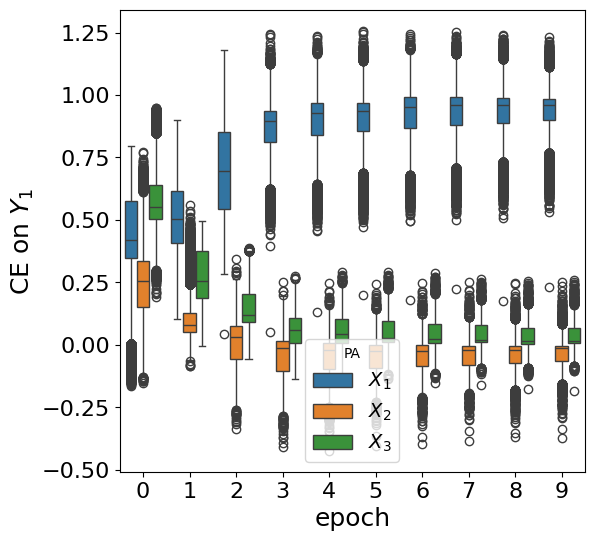

In [5]:
fig, ax = plt.subplots()
sns.boxplot(data=df.set_index("i").loc[0], x="epoch", y="value_denorm", hue="PA")
ax.set_ylabel("CE on $Y_1$")


Text(0, 0.5, 'CE on $Y_2$')

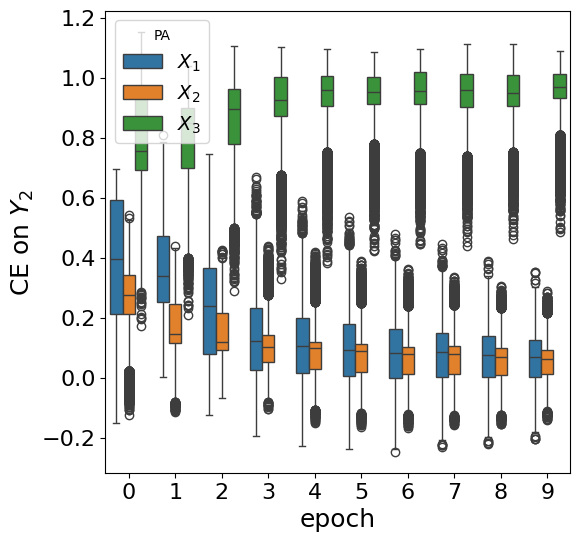

In [6]:
fig, ax = plt.subplots()
sns.boxplot(data=df.set_index("i").loc[1], x="epoch", y="value_denorm", hue="PA")
ax.set_ylabel("CE on $Y_2$")

Text(0, 0.5, 'CE on $Y_3$')

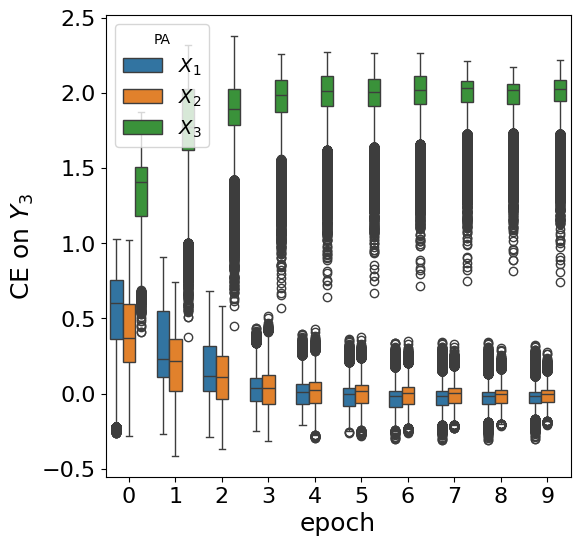

In [7]:
fig, ax = plt.subplots()
sns.boxplot(data=df.set_index("i").loc[2], x="epoch", y="value_denorm", hue="PA")
ax.set_ylabel("CE on $Y_3$")

In [39]:
data["batch_0"].shape
jacob = data["batch_0"][:,:,0,:,0]
jacob.shape

(64, 3, 3)

In [40]:
jacob.std(axis=0)

array([[0.02149613, 0.04170129, 0.08710348],
       [0.0271435 , 0.04740385, 0.08154081],
       [0.03093258, 0.06741476, 0.14100893]], dtype=float32)

In [41]:


def array_to_long_df(arr):
    """
    Convert a B x M1 x M2 numpy array to a long DataFrame.

    Parameters:
    arr (np.ndarray): Input array of shape (B, M1, M2)

    Returns:
    pd.DataFrame: DataFrame with columns 'batch', 'i', 'j', 'value'
    """
    B, M1, M2 = arr.shape
    # Reshape and create indices
    df = pd.DataFrame({
        'sample': np.repeat(np.arange(B), M1 * M2),
        'i': np.tile(np.repeat(np.arange(M1), M2), B),
        'j': np.tile(np.arange(M2), B * M1),
        'value': arr.reshape(-1)
    })
    return df

df_epoch = array_to_long_df(jacob)
df_epoch["epoch"] = 0
df_epoch

,sample,i,j,value,epoch
0,0,0,0,0.154685,0
1,0,0,1,0.206235,0
2,0,0,2,0.509886,0
3,0,1,0,0.265976,0
4,0,1,1,0.299034,0
...,...,...,...,...,...
571,63,1,1,0.208247,0
572,63,1,2,0.283359,0
573,63,2,0,0.200514,0
574,63,2,1,0.226494,0
